<a href="https://colab.research.google.com/github/jupinzonri/Taller2/blob/main/Taller_2_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller 2: Autómatas Celulares
**Nombre:** Juan Felipe Pinzón Rincón

## 2.10 Ejercicios y Problemas

### 1. Reglas básicas de comportamiento en distintos escenarios
Las personas actuamos como autómatas celulares mediante una serie de reglas implícitas que definen nuestro comportamiento. Mis reglas se definirían de la siguiente manera:
* **En casa:** Si es de noche y terminé mis asignaciones, procedo a realizar mi rutina personal y descansar; si es de día y hay trabajo pendiente, enciendo la laptop para programar modelos en Python.
* **En la Universidad:** Si es hora de clase, me dirijo al aula correspondiente; si tengo un bloque libre, voy a la biblioteca a estudiar o avanzar en proyectos.
* **En el medio de transporte (conduciendo):** Si el semáforo está en rojo o el vehículo de adelante frena, piso el freno para detenerme; si la vía está libre y el semáforo en verde, acelero manteniendo la velocidad permitida.

### 2. Modelo de difusión usando ACs probabilísticos (Enfermedad)
Los autómatas celulares probabilísticos utilizan reglas para emular contagios espaciales.
* **Estados:** Sano (0), Contagiado (1), Recuperado (2).
* **Regla de contagio:** Si una célula sana tiene al menos un vecino contagiado, se contagia con cierta probabilidad.
* **Regla de recuperación:** Tras un tiempo determinado, la célula pasa a estado recuperado.
*(El código de simulación se encuentra en el archivo Python adjunto en este repositorio)*

### 3. Comportamiento de un robot con tres sensores de distancia
El robot opera mediante autómatas celulares no uniformes.
* **Sensores pasivos:** Centro (C), Derecho (D), Izquierdo (I) detectan obstáculos en distintos rangos.
* **Actuadores activos:** Motor Izquierdo (Mi) y Motor Derecho (Md).
* **Lógica de evasión:** Cuando el sensor central detecta un objeto en distancia crítica, la regla de transición invierte un motor y apaga el otro para evitar la colisión frontal, permitiendo la rotación sobre su propio eje.
*(La lógica algorítmica programada se encuentra en el archivo Python adjunto)*

### 4. Análisis con Diagramas de Voronoi en una ciudad
Los diagramas de Voronoi permiten dividir espacios físicos en zonas de influencia basadas en la proximidad.
* **Análisis de cobertura:** Si un polígono de Voronoi (por ejemplo, para un colegio o centro de salud) es inusualmente grande, indica un déficit de cobertura y obliga a los ciudadanos a realizar grandes desplazamientos.
* **Relación entre diagramas:** Al cruzar los diagramas de distintas infraestructuras, las áreas con polígonos densos y pequeños coincidirán con los focos de mayor desarrollo urbano.
*(El script de generación gráfica se encuentra en el archivo Python adjunto)*

=== SIMULACIÓN DE ENFERMEDAD (Estado Final) ===
Sanos: 191 | Contagiados: 152 | Recuperados: 57

=== PRUEBA DE ROBOT ===
Sensores: [Izq: Libre, Centro: Crítico, Der: Libre]
Acción de motores (Motor Izq, Motor Der): (2, 0)

=== GENERANDO DIAGRAMA DE VORONOI ===


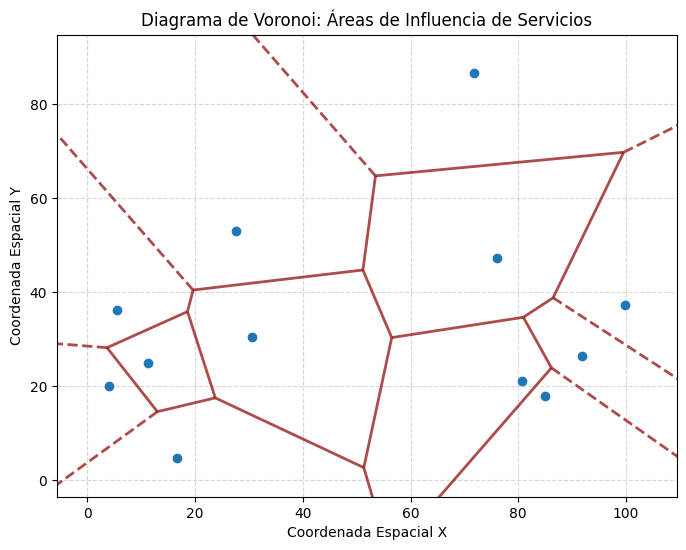

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d

# ==========================================
# 2. Modelo de difusión usando ACs probabilísticos (Enfermedad)
# ==========================================
def simular_difusion_enfermedad(ciclos=20, tamano=50, prob_contagio=0.3, prob_recuperacion=0.1):
    # Inicialización del retículo: 0 = Sano, 1 = Contagiado, 2 = Recuperado
    grid = np.zeros((tamano, tamano))

    # Introducir casos iniciales aleatorios (Pacientes cero)
    grid[tamano//2, tamano//2] = 1
    grid[tamano//3, tamano//3] = 1

    historial_grid = [grid.copy()]

    for _ in range(ciclos):
        nuevo_grid = grid.copy()
        for i in range(tamano):
            for j in range(tamano):
                estado = grid[i, j]

                # Evaluar la vecindad de Moore (3x3)
                vecinos = grid[max(0, i-1):min(tamano, i+2), max(0, j-1):min(tamano, j+2)]

                if estado == 0:
                    contagiados_cerca = np.sum(vecinos == 1)
                    if contagiados_cerca > 0 and np.random.rand() < prob_contagio:
                        nuevo_grid[i, j] = 1
                elif estado == 1:
                    if np.random.rand() < prob_recuperacion:
                        nuevo_grid[i, j] = 2

        grid = nuevo_grid
        historial_grid.append(grid.copy())

    return historial_grid

# ==========================================
# 3. Comportamiento de un robot con tres sensores de distancia
# ==========================================
def regla_evasion_robot(sensor_izq, sensor_centro, sensor_der):
    """
    Entradas (distancia): 0 (Crítico), 1 (Medio), 2 (Libre)
    Salidas (Motor Izq, Motor Der): 0 (Apagado), 1 (Adelante), 2 (Atrás)
    """
    if sensor_centro == 0:
        return (2, 0) # Obstáculo inminente al frente: Rotar sobre su eje
    elif sensor_izq == 0:
        return (1, 0) # Obstáculo a la izquierda: Evadir hacia la derecha
    elif sensor_der == 0:
        return (0, 1) # Obstáculo a la derecha: Evadir hacia la izquierda
    else:
        return (1, 1) # Espacio libre: Avanzar en línea recta

# ==========================================
# 4. Análisis con Diagramas de Voronoi en una ciudad
# ==========================================
def generar_voronoi_ciudad():
    # Simular coordenadas (x, y) de servicios en la ciudad
    np.random.seed(15)
    puntos_servicios = np.random.rand(12, 2) * 100

    # Calcular las regiones de Voronoi
    vor = Voronoi(puntos_servicios)

    # Generar la visualización
    fig, ax = plt.subplots(figsize=(8, 6))
    voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='darkred', line_width=2, line_alpha=0.7, point_size=12)

    ax.set_title("Diagrama de Voronoi: Áreas de Influencia de Servicios")
    ax.set_xlabel("Coordenada Espacial X")
    ax.set_ylabel("Coordenada Espacial Y")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# 1. Ejecutar y visualizar un resumen de la simulación de enfermedad
historial = simular_difusion_enfermedad(ciclos=10, tamano=20)
estado_final = historial[-1]
sanos = np.sum(estado_final == 0)
contagiados = np.sum(estado_final == 1)
recuperados = np.sum(estado_final == 2)

print("=== SIMULACIÓN DE ENFERMEDAD (Estado Final) ===")
print(f"Sanos: {sanos} | Contagiados: {contagiados} | Recuperados: {recuperados}\n")

# 2. Probar la regla de evasión del robot
# Ejemplo: Obstáculo crítico al frente (0), izquierda libre (2), derecha libre (2)
accion = regla_evasion_robot(sensor_izq=2, sensor_centro=0, sensor_der=2)
print("=== PRUEBA DE ROBOT ===")
print(f"Sensores: [Izq: Libre, Centro: Crítico, Der: Libre]")
print(f"Acción de motores (Motor Izq, Motor Der): {accion}\n")

# 3. Ejecutar y mostrar el Diagrama de Voronoi
print("=== GENERANDO DIAGRAMA DE VORONOI ===")
generar_voronoi_ciudad()
